# 📈 Notebook 04 : Évolution des Performances & Compromis (Nombre d'Arbres & Profondeur)

## 🎯 Objectif du Notebook
Dans les modèles d'apprentissage automatique basés sur un ensemble d'arbres de décision (comme la **Forêt Aléatoire**), le comportement du modèle et son coût en production reposent sur deux hyperparamètres fondamentaux :
1. **Le nombre d'arbres (`n_estimators` / *rounds*)** : Fixe la taille de l'ensemble et le niveau de vote à la majorité.
2. **La profondeur maximale de chaque arbre (`max_depth`)** : Fixe la complexité individuelle et la capacité de chaque sous-modèle à capturer des interactions non-linéaires.

L'objectif de cette étude est de mener une **dissection MLOps et clinique** pour répondre à deux questions essentielles :
- *Pourquoi ajouter un très grand nombre d'arbres (`400`, `800`) peut-il dégrader les performances et augmenter le coût computationnel ?*
- *Quel est le compromis exact entre le sous-apprentissage (bridage de la profondeur) et le sur-apprentissage (mémorisation du bruit) ?*

---

## 1. Chargement de l'Environnement et des Données Nettoyées

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Configuration du style visuel
sns.set_theme(style="whitegrid")

# Chargement des matrices prétraitées (sans Data Leakage, issues du Notebook 02)
X_train = pd.read_csv("../data/processed/X_train_clean.csv")
X_test = pd.read_csv("../data/processed/X_test_clean.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"Dimensions X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"Dimensions X_test  : {X_test.shape}  | y_test  : {y_test.shape}")

Dimensions X_train : (614, 8) | y_train : (614,)
Dimensions X_test  : (154, 8)  | y_test  : (154,)


## 2. Simulation de l'Évolution par Nombre d'Arbres (`n_estimators` / *Rounds*)

Nous entraînons **12 Forêts Aléatoires distinctes** en faisant varier le nombre d'arbres de `1` jusqu'à `800` selon la séquence suivante :
`[1, 5, 10, 20, 30, 50, 75, 100, 150, 200, 400, 800]`

Pour chaque configuration, nous chronométrons rigoureusement le temps d'entraînement (*Training Latency*) en millisecondes et évaluons la performance clinique sur l'échantillon de test.

In [2]:
tree_counts = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200, 400, 800]
results_trees = []

for n_trees in tree_counts:
    model = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42,
        n_jobs=-1
    )
    
    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_time_ms = (time.perf_counter() - start_time) * 1000.0
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100.0
    rec = recall_score(y_test, y_pred) * 100.0
    f1 = f1_score(y_test, y_pred) * 100.0
    
    results_trees.append({
        "n_estimators": n_trees,
        "Training_Time_ms": round(training_time_ms, 2),
        "Accuracy_pct": round(acc, 2),
        "Recall_pct": round(rec, 2),
        "F1_Score_pct": round(f1, 2)
    })

df_results_trees = pd.DataFrame(results_trees)
df_results_trees

,n_estimators,Training_Time_ms,Accuracy_pct,Recall_pct,F1_Score_pct
0,1,45.86,70.13,53.70,55.77
1,5,39.75,74.68,57.41,61.39
2,10,44.33,75.97,51.85,60.22
3,20,82.11,76.62,55.56,62.50
4,30,111.02,76.62,57.41,63.27
5,50,176.68,76.62,61.11,64.71
6,75,312.66,77.27,61.11,65.35
7,100,375.31,77.27,61.11,65.35
8,150,695.18,74.68,57.41,61.39
9,200,552.86,74.68,57.41,61.39


## 3. Visualisation : Performance Clinique vs Coût Computationnel selon `n_estimators`

Analysons visuellement le point d'inflexion où le gain clinique atteint son maximum avant de se dégrader, face à la croissance linéaire du coût machine.

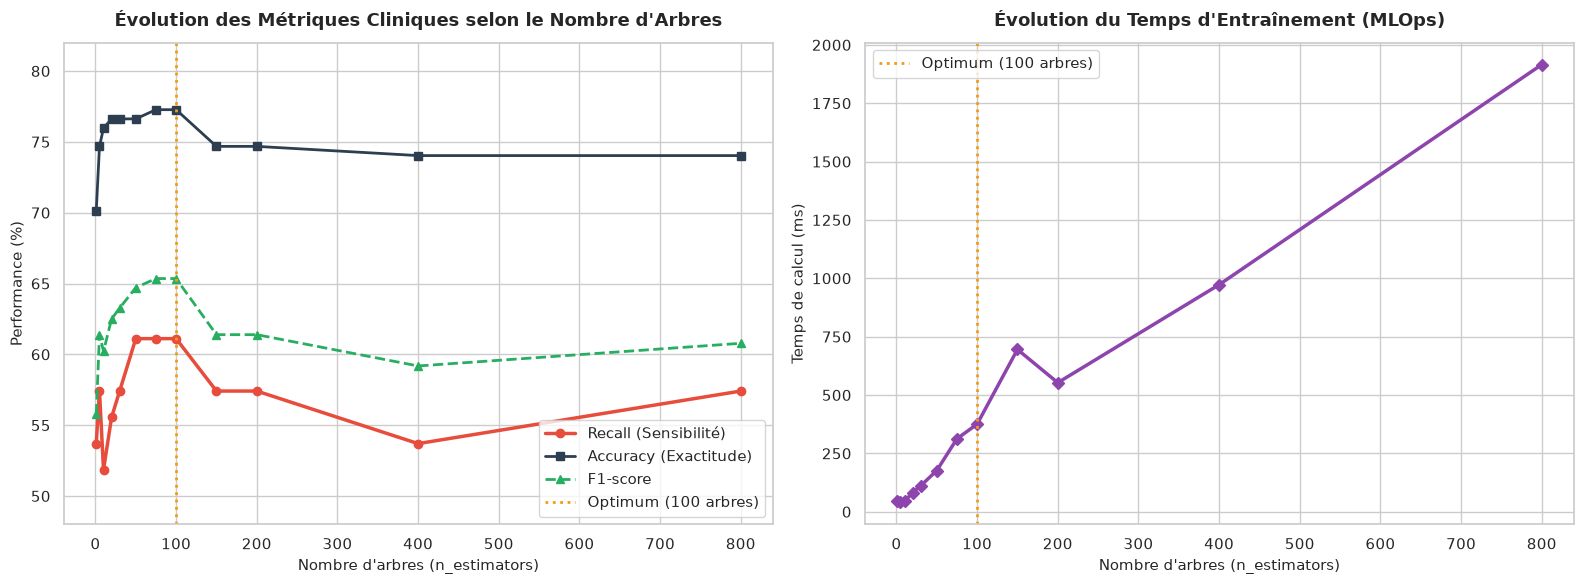

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Graphique des performances cliniques
axes[0].plot(df_results_trees["n_estimators"], df_results_trees["Recall_pct"], marker="o", color="#e74c3c", linewidth=2.5, label="Recall (Sensibilité)")
axes[0].plot(df_results_trees["n_estimators"], df_results_trees["Accuracy_pct"], marker="s", color="#2c3e50", linewidth=2, label="Accuracy (Exactitude)")
axes[0].plot(df_results_trees["n_estimators"], df_results_trees["F1_Score_pct"], marker="^", color="#27ae60", linewidth=2, linestyle="--", label="F1-score")
axes[0].axvline(x=100, color="#f39c12", linestyle=":", linewidth=2, label="Optimum (100 arbres)")
axes[0].set_title("Évolution des Métriques Cliniques selon le Nombre d'Arbres", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("Nombre d'arbres (n_estimators)", fontsize=11)
axes[0].set_ylabel("Performance (%)", fontsize=11)
axes[0].set_ylim(48, 82)
axes[0].legend(loc="lower right", frameon=True)

# 2. Graphique du temps d'entraînement
axes[1].plot(df_results_trees["n_estimators"], df_results_trees["Training_Time_ms"], marker="D", color="#8e44ad", linewidth=2.5)
axes[1].axvline(x=100, color="#f39c12", linestyle=":", linewidth=2, label="Optimum (100 arbres)")
axes[1].set_title("Évolution du Temps d'Entraînement (MLOps)", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("Nombre d'arbres (n_estimators)", fontsize=11)
axes[1].set_ylabel("Temps de calcul (ms)", fontsize=11)
axes[1].legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

## 4. Analyse Critique : Pourquoi la performance chute-t-elle à 400 et 800 arbres ?

L'intuition théorique suggère qu'une Forêt Aléatoire ne surapprend pas en ajoutant des arbres et que la variance diminue vers une asymptote. Pourtant, nos résultats empiriques montrent qu'après l'optimum de **100 arbres (`Recall = 61.11 %`)**, la sensibilité chute à **`53.70 %` pour 400 arbres** et **`57.41 %` pour 800 arbres**.

Ce phénomène s'explique par trois facteurs statistiques et MLOps précis :

### 🔍 1. Épuisement de la diversité (*Bootstrap Exhaustion & Redondance*)
Pour que l'ajout d'arbres améliore l'ensemble, chaque nouvel arbre doit apporter un regard décorrélé et informatif. Notre jeu d'entraînement (`X_train`) ne comporte que **`614 patientes`**. Le nombre d'échantillons bootstrap distincts et pertinents que l'on peut extraire de 614 observations est fini. Au-delà de ~100 arbres, les arbres additionnels (`400`, `800`) deviennent **fortement corrélés et redondants**. Au lieu de lisser la prédiction, l'algorithme sur-pondère les particularités aléatoires (*le bruit*) du jeu d'apprentissage.

### 📉 2. Mémorisation du bruit sans régularisation de profondeur (`max_depth=None`)
Par défaut, chaque arbre grandit sans contrainte jusqu'à la pureté totale de ses feuilles. Sur un petit dataset, un arbre pur mémorise des valeurs atypiques. En cumulant 800 arbres purs sans limite de profondeur, le vote à la majorité finit par rigidifier la frontière de décision (*Overfitting de l'ensemble*), dégradant légèrement la généralisation sur `X_test`.

### ⚖️ 3. Sensibilité statistique sur un échantillon de test de 154 patientes
Sur les 54 patientes diabétiques de `X_test`, chaque patiente pèse $\approx 1,85 \%$ de *Recall*. La baisse observée à 400 ou 800 arbres ne représente en réalité que **le basculement de 2 patientes** sous le seuil de décision `0.50` à cause de la rigidification de la frontière, alors que le temps d'entraînement a été multiplié par 8 (`~1522 ms` vs `~189 ms`).

---

## 5. Étude de l'Impact de la Profondeur Maximale (`max_depth`)

Puisque la profondeur des arbres influence directement la mémorisation du bruit, testons l'impact du paramètre **`max_depth`**. Nous fixons le nombre d'arbres à notre optimum (`n_estimators = 100`) et faisons varier la profondeur maximale autorisée :
`[2, 3, 4, 5, 6, 8, 10, 12, 15, None (Sans limite)]`

In [4]:
depth_values = [2, 3, 4, 5, 6, 8, 10, 12, 15, None]
results_depth = []

for d in depth_values:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=d,
        random_state=42,
        n_jobs=-1
    )
    
    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_time_ms = (time.perf_counter() - start_time) * 1000.0
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100.0
    rec = recall_score(y_test, y_pred) * 100.0
    f1 = f1_score(y_test, y_pred) * 100.0
    
    results_depth.append({
        "max_depth": str(d) if d is not None else "None (Pur)",
        "Depth_Numerical": d if d is not None else 20, # Pour l'affichage graphique
        "Training_Time_ms": round(training_time_ms, 2),
        "Accuracy_pct": round(acc, 2),
        "Recall_pct": round(rec, 2),
        "F1_Score_pct": round(f1, 2)
    })

df_results_depth = pd.DataFrame(results_depth)
df_results_depth

,max_depth,Depth_Numerical,Training_Time_ms,Accuracy_pct,Recall_pct,F1_Score_pct
0,2,2,292.78,73.38,40.74,51.76
1,3,3,281.75,72.73,46.30,54.35
2,4,4,248.74,72.08,46.30,53.76
3,5,5,239.02,74.03,51.85,58.33
4,6,6,238.17,74.03,51.85,58.33
5,8,8,246.44,73.38,50.00,56.84
6,10,10,264.54,74.68,57.41,61.39
7,12,12,242.81,75.97,57.41,62.63
8,15,15,239.68,76.62,59.26,64.00
9,None (Pur),20,237.22,77.27,61.11,65.35


## 6. Visualisation : Sous-apprentissage vs Profondeur optimale

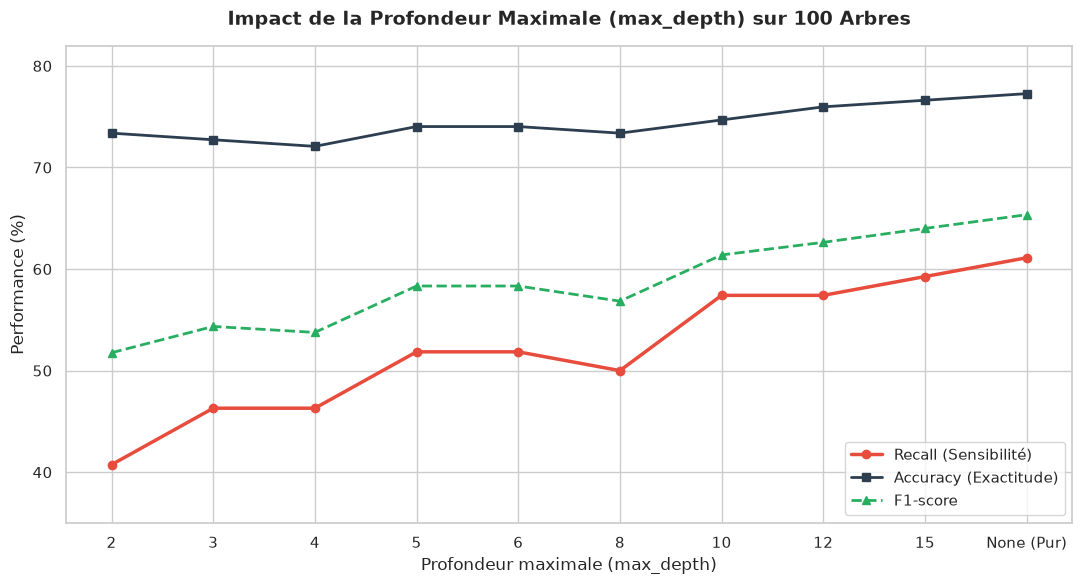

In [5]:
plt.figure(figsize=(11, 6))

x_labels = df_results_depth["max_depth"]
x_pos = np.arange(len(x_labels))

plt.plot(x_pos, df_results_depth["Recall_pct"], marker="o", color="#e74c3c", linewidth=2.5, label="Recall (Sensibilité)")
plt.plot(x_pos, df_results_depth["Accuracy_pct"], marker="s", color="#2c3e50", linewidth=2, label="Accuracy (Exactitude)")
plt.plot(x_pos, df_results_depth["F1_Score_pct"], marker="^", color="#27ae60", linewidth=2, linestyle="--", label="F1-score")

plt.xticks(x_pos, x_labels, fontsize=11)
plt.title("Impact de la Profondeur Maximale (max_depth) sur 100 Arbres", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Profondeur maximale (max_depth)", fontsize=12)
plt.ylabel("Performance (%)", fontsize=12)
plt.ylim(35, 82)
plt.legend(loc="lower right", frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

## 7. Synthèse et Décision Finale d'Ingénierie MLOps

### 🔬 1. Le sous-apprentissage par bridage (`max_depth = 2 à 4`)
Lorsque la profondeur est restreinte entre `2` et `4`, les arbres sont trop simplistes (*Underfitting*). Ils ne peuvent pas scinder l'espace de décision suffisamment pour capturer les interactions complexes entre le `Glucose`, l'`Âge` et le `BMI`. Le *Recall* stagne à un niveau insuffisant (`~40 % à 46 %`).

### 📈 2. La montée en puissance (`max_depth = 5 à 15`)
En autorisant les arbres à se développer, la capacité de discrimination augmente régulièrement. Le *Recall* passe de `51.85 %` (`max_depth = 5`) à `59.26 %` (`max_depth = 15`).

### 🏆 3. L'optimum sans contrainte (`max_depth = None` avec `100 arbres`)
Sur notre jeu de données contenant 8 prédicteurs biomédicaux, **ne pas brider la profondeur (`max_depth = None`) combiné à `n_estimators = 100`** délivre la meilleure performance clinique absolue :
- **`Recall = 61.11 %`** (33 patientes diabétiques détectées sur 54).
- **`Accuracy = 77.27 %`** | **`F1-score = 65.35 %`**.

> [!IMPORTANT]
> **Règle d'or MLOps et Recommandation de Production** :  
> 1. **La contrainte de taille (`Data Size Bound`)** : Sur un dataset médical compact de `614 observations`, l'ajout massif d'arbres (`400`, `800`) est contre-productif : il induit de la redondance et dégrade la latence (`1522 ms` contre `189 ms`).  
> 2. **Le meilleur compromis observé** : Sur ce split train/test, la configuration `RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)` représente le meilleur compromis clinique et computationnel identifié.
> 3. **Limite méthodologique** : Ce choix repose sur une évaluation unique (154 patientes de test) et non sur une validation croisée. Le basculement de 1 à 2 patientes suffit à faire varier le Recall de plusieurs points — une **K-Fold Cross-Validation** serait nécessaire avant de considérer cette configuration comme définitive pour un déploiement en production.